# Exploratory Data Analysis

Dataset: [Credit Card Application from Kaggle](https://www.kaggle.com/datasets/nazishjaveed/credit-card-application/data)

Analysis by: Luis Gerardo Ramirez Archundia

In [23]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [4]:
# basic
import sys
from pathlib import Path
root=Path.cwd().parent
sys.path.append(str(root/"src"))

# data library
import pandas as pd
import numpy as np

# plotting and visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# data path
from config import DATA_PATH


# Data

In [5]:
df=pd.read_csv(DATA_PATH)
# dropping CustomerID columns
df=df.drop(columns=["CustomerID"])

In [6]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [7]:
# general info about dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    int64  
 1   A2      690 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    int64  
 4   A5      690 non-null    int64  
 5   A6      690 non-null    int64  
 6   A7      690 non-null    float64
 7   A8      690 non-null    int64  
 8   A9      690 non-null    int64  
 9   A10     690 non-null    int64  
 10  A11     690 non-null    int64  
 11  A12     690 non-null    int64  
 12  A13     690 non-null    int64  
 13  A14     690 non-null    int64  
 14  Class   690 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 81.0 KB


# Target variable distribution

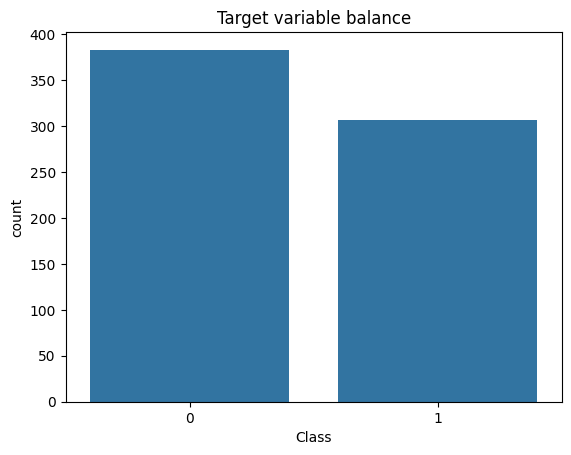

In [8]:
fig=sns.countplot(data=df, x="Class")
fig.set_title("Target variable balance")

plt.show()

# Categorical variables

In [9]:
# getting categorical (int64) and numerical (float64) variables
cat_cols=[]
num_cols=[]
for col in df.columns:
    if df[col].dtypes=="int64":
        cat_cols.append(col)
    elif df[col].dtypes=="float64":
        num_cols.append(col)

In [10]:
print(f"Number of categorical columns: {len(cat_cols)}")
print(cat_cols)

Number of categorical columns: 12
['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'Class']


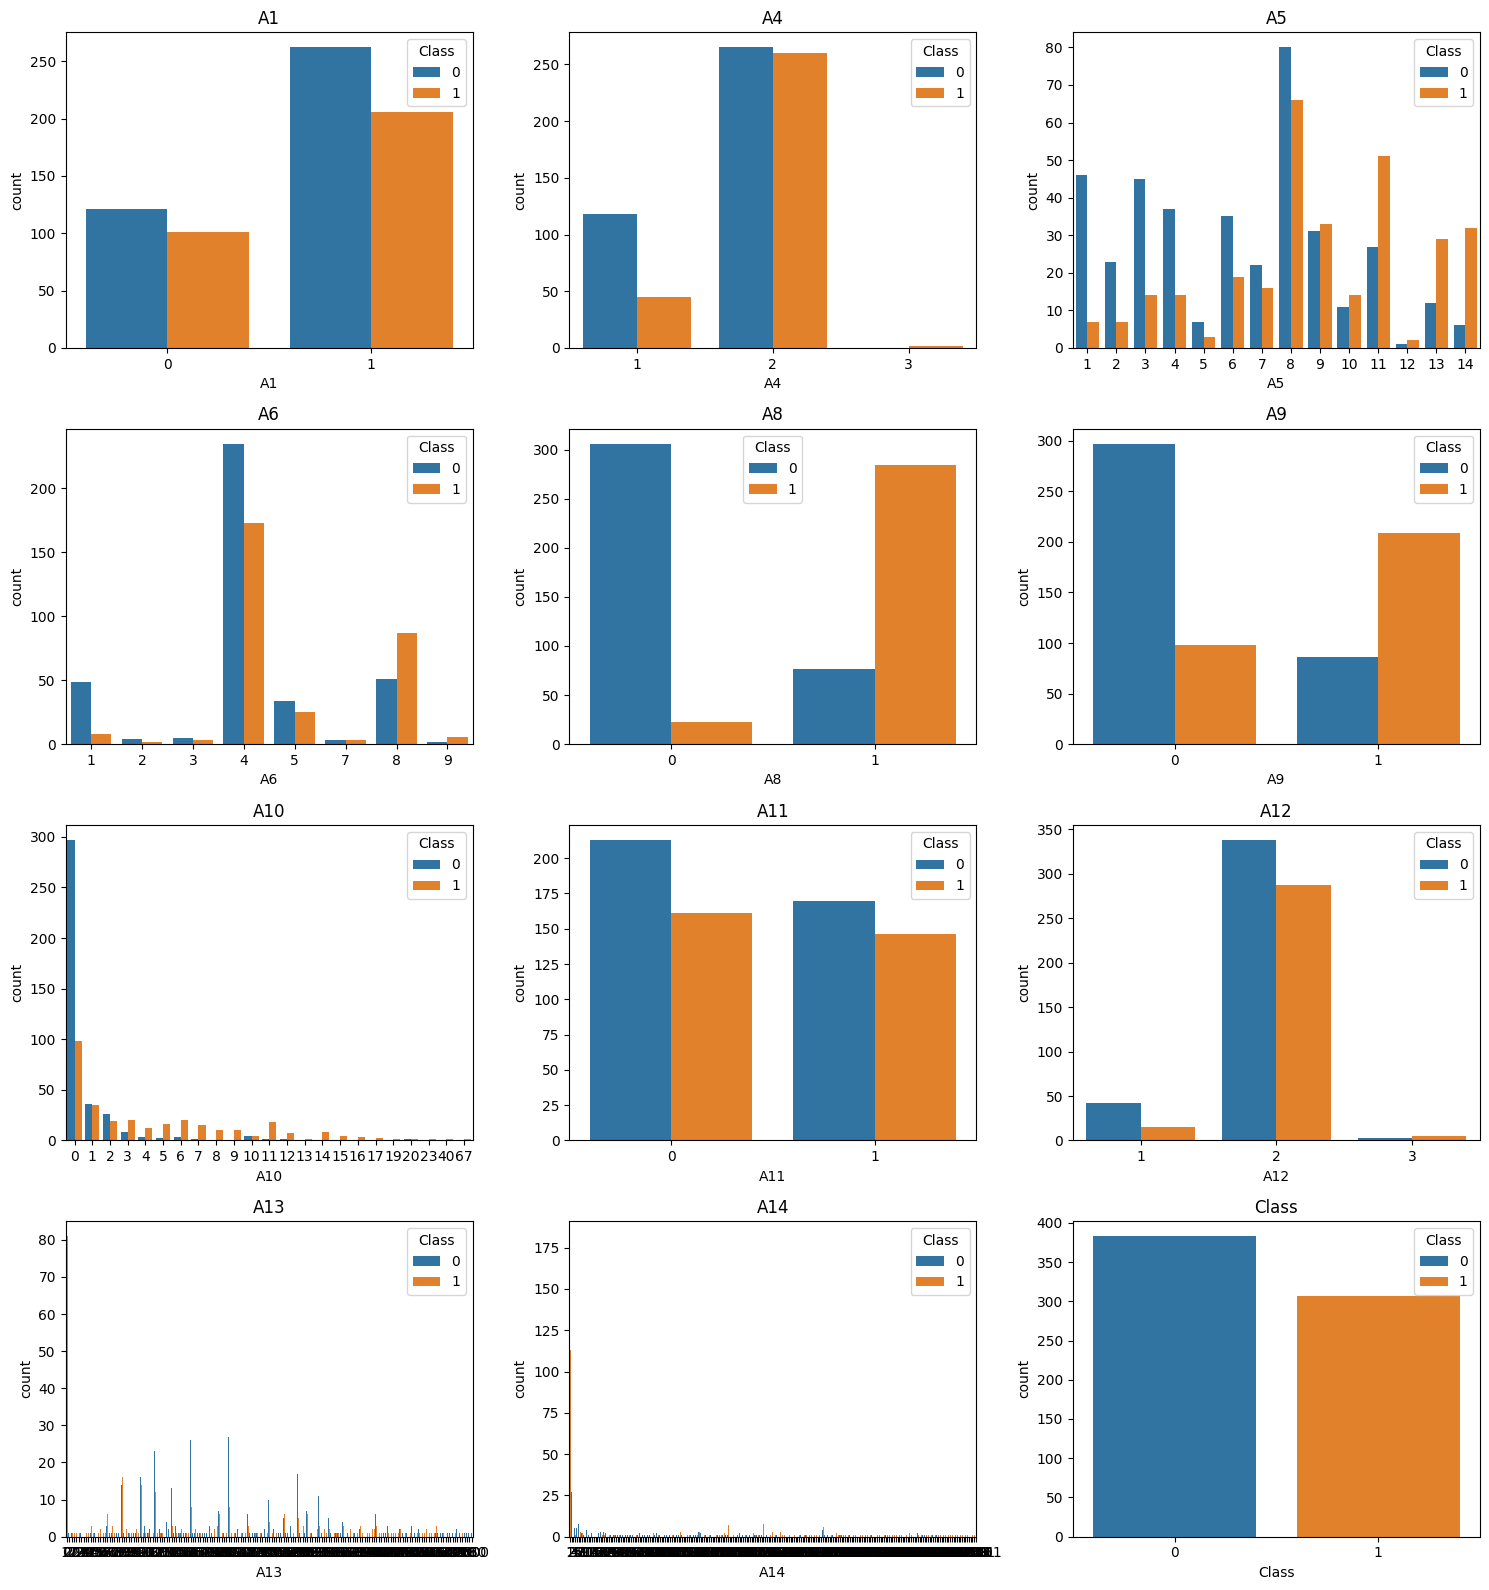

In [11]:
"""
    Plotting categorical columns
"""
# setting lenght of cat variables 
n=len(cat_cols)

# makin subplots
ncols=3
nrows=int(np.ceil(n/ncols))

fig, axes=plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes=axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df[cat_cols], x=col, ax=axes[i], hue="Class")
    axes[i].set_title(col)
    

plt.tight_layout()
plt.show()

- Variables A13 and A14 have a wide range and non-uniform distribution of values, it is advisable to analyze them sparately
- A1, A4, A5, A10 and A12 are unbalanced

## Columns A13 and A14

In [12]:
def unique_values_count(df, column):
    """
        Count unique values from a categoric column
    """
    size=df[column].value_counts().shape
    print(f"The column {column} has {size[0]} distinct values ")

unique_values_count(df, "A13")
unique_values_count(df, "A14")

The column A13 has 171 distinct values 
The column A14 has 240 distinct values 


Estas columnas tienen una alta cardinalidad.

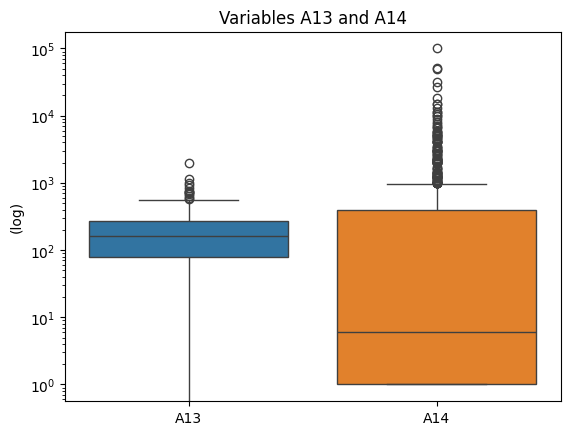

In [13]:
sns.boxplot(data=df[["A13", "A14"]])
plt.yscale("log")
plt.title("Variables A13 and A14")
plt.ylabel("(log)")

plt.show()

- Hay una presencia importante de valores atípicos, especialmente en A14.
- Los valores de A14 están muy dispersos respecto a la mediana, por otro lado A13 tiene una distribución más concentrada.


### Case A13

In [14]:
A13_column=df["A13"].value_counts().reset_index().sort_values(by="count", ascending=False)
# msotramos el top 5 de frecuencias
print(A13_column.head(5))
# mostramos una descripción general de estos valores
A13_column["count"].describe()

   A13  count
0    0    132
1  200     35
2  120     35
3  160     34
4  100     30


count    171.000000
mean       4.035088
std       11.576292
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      132.000000
Name: count, dtype: float64

- The most frequent value in A13 is “0,” with 132 occurrences. Measures of central tendency indicate that the values are widely dispersed, with a standard deviation of 11.5 from the mean.
- The average frequency of these data is 1 occurrence

### Case 14

In [15]:
A14_column=df["A14"].value_counts().reset_index().sort_values(by="count", ascending=False)
print(A14_column.head(5))
# descripción general de los datos
A14_column["count"].describe()

    A14  count
0     1    295
1     2     29
2   501     10
3  1001     10
4     3      9


count    240.000000
mean       2.875000
std       19.074644
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      295.000000
Name: count, dtype: float64

- “1” is the value with the highest number of occurrences in column A14, with a wide gap between second and third place.
- The mean is relatively close to the median of the data, but the standard deviation is very large, indicating considerable dispersion among the data.

## Which of these two columns has the highest frequency?


Text(0, 0.5, 'Class size')

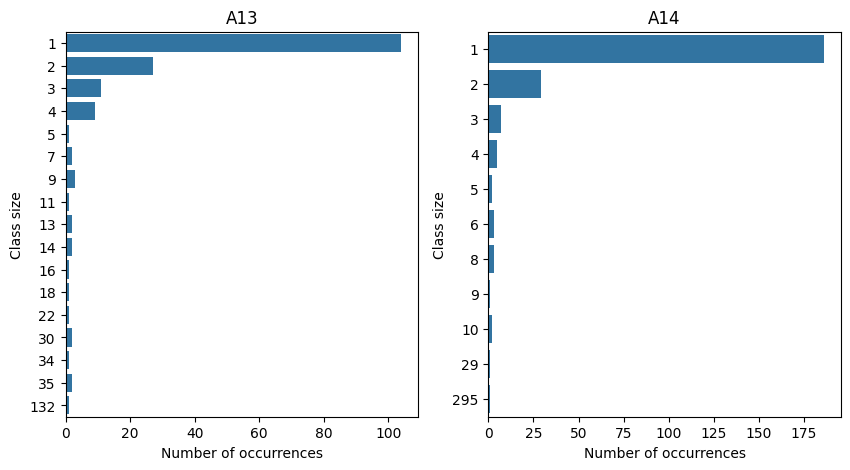

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax.flatten()
sns.countplot(A13_column, y="count", ax=ax[0])
sns.countplot(A14_column, y="count", ax=ax[1])

# Plot adjustments
ax[0].set_title("A13")
ax[0].set_xlabel("Number of occurrences")
ax[0].set_ylabel("Class size")

ax[1].set_title("A14")
ax[1].set_xlabel("Number of occurrences")
ax[1].set_ylabel("Class size")

This pair of plots shows the distribution of class frequencies for each column. After calculating the size of each class using `value_counts()`, this chart analyzes how those sizes are distributed. The goal is to identify whether the data is concentrated in a few dominant classes or evenly distributed.

Both columns display nearly the same behavior: a class size of "1" is by far the most frequent, and from size 4 onwards, the frequency count decreases significantly.

# Numerical varaibles

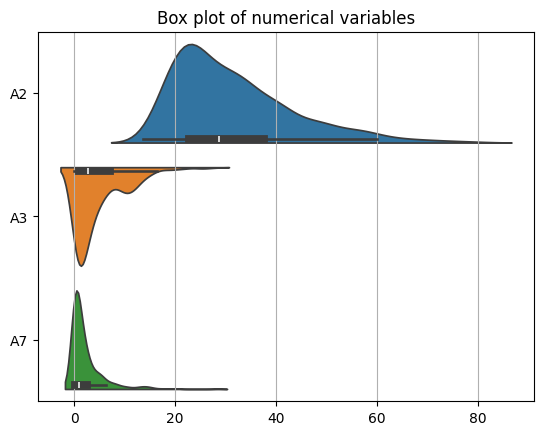

In [17]:
# Now for the numerical variables
fig = sns.violinplot(df[num_cols], split=True, orient="h")
fig.grid(axis="x")
fig.set_title("Box plot of numerical variables")
plt.show()

In [18]:
df["A2"].describe()

count    690.000000
mean      31.568203
std       11.853273
min       13.750000
25%       22.670000
50%       28.625000
75%       37.707500
max       80.250000
Name: A2, dtype: float64

In [19]:
df["A3"].describe()

count    690.000000
mean       4.758725
std        4.978163
min        0.000000
25%        1.000000
50%        2.750000
75%        7.207500
max       28.000000
Name: A3, dtype: float64

In [20]:
df["A7"].describe()

count    690.000000
mean       2.223406
std        3.346513
min        0.000000
25%        0.165000
50%        1.000000
75%        2.625000
max       28.500000
Name: A7, dtype: float64


### A2
- Markedly right-skewed distribution, with a long tail extending to values above 85 and 90.
- Most of the density is concentrated within the 20 to 40 range.

### A3
- This distribution shows a more extreme positive skew (long tail to the right).
- The box plot is compressed to the left, with the median very close to 0.
- The long tail extends to around 30, which are likely outliers.
- The density increases slightly near 10.

### A7
- An extremely right-skewed distribution, with a mean close to zero.
- The box is heavily compressed around zero, with a nearby median.

### General Analysis
Since A3 and A7 have long tails, it is worth conducting a deeper analysis to determine whether these values are outliers or if they encode a specific characteristic of the population.

## Correlations

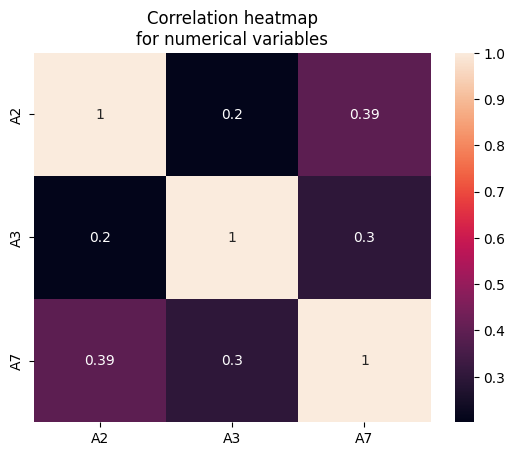

In [21]:
corr = df[num_cols].corr()
fig = sns.heatmap(corr, annot=True)
fig.set_title("Correlation heatmap\nfor numerical variables")
plt.show()

No significant correlations are observed between these variables.

## Relationship with the Target

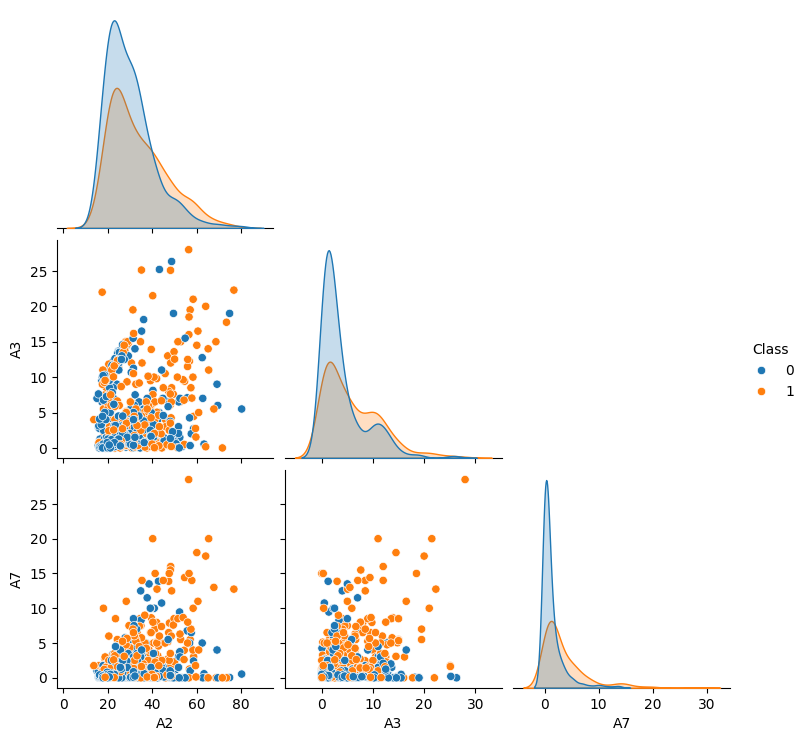

In [22]:
sns.pairplot(
    data=df[num_cols+["Class"]],
    hue="Class",
    corner=True
)
plt.show()

None of the predictors manage to clearly segment the target variable. In the joint distributions, no distinct difference can be observed between class 0 and class 1.

# Conclusions

- The target class does not exhibit a significant imbalance.
- The dataset contains 12 categorical variables and 3 numerical variables.
- Predictors A13 and A14 deserve special attention due to their high cardinality, with A13 having 171 unique values and A14 having 240 unique values.
  - In A13, label 0 has by far the highest number of occurrences.
  - In A14, the most frequent label was 1.
  - In both columns, the most frequent class size was 1, meaning that most labels appear only once.